In [1]:
import torch
import pandas as pd
from PIL import Image
import os 
import numpy as np
import json
from glob import glob
import pandas as pd
import sys
sys.path.append("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/segmentation/")
sys.path.append("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/WGM_separation/")
from train_seg_dinov3vit_unet import DINOv3_UNet
import cv2
import json

/home/mahirwar/miniconda3/envs/transform/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Identify White Matter

In [33]:
questions = [
    "what kind of matter is this? Explain what you see in attention map",
    "Which type of brain matter is shown here? Describe what is visible in the attention map.",

"Identify whether this represents gray or white matter, and interpret the attention map.",

"Determine the matter type in this image and explain the patterns in the attention overlay.",

"What brain matter does this image depict? Discuss the key regions highlighted in the attention map.",

"Can you tell if this image shows gray or white matter? Describe the focus areas in the attention visualization."
]

In [6]:
answers= {"0":"White Matter. Attention Map",
          "1":"White Matter. No Attention Map",
          "2":"Gray Matter. Attention Map. Red - Lewy Bodies, Yellow - Oligodendrites",
          "3":"Gray Matter. No Attention Map",
          "4":"Torn Image. Attention Map",
          "5":"Torn Image. No Attention Map",
          "6":"Gray Matter. Attention Map. Red - Lewy Bodies, Lewy Neurites, Yellow - Dark small aggregates ",
          "7":"Background",
          "8":"Gray Matter. Attention Map. Red - Lewy Bodies, Orange/Yellow - Lewy Neurites, Dark small aggregates",
          "9":"Gray Matter. Attention Map. Red - Lewy Bodies, Yellow - Neurons/small aggregates, Blue - Glial Cells",
          

}

In [10]:
image_folder = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/images"

In [11]:
images = glob(os.path.join(image_folder,"*.png"))

In [12]:
len(images)

240

In [13]:
images[0]

'/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/images/PD92_C110-115_EntCx_files_84_61.png'

In [17]:
json_folder = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/json"

In [18]:
all_jsons = []

In [19]:
images[11]

'/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/images/DLB-99-1147-C34-45-EntCxDam-Hippocampus_files_76_50.pngattn.png'

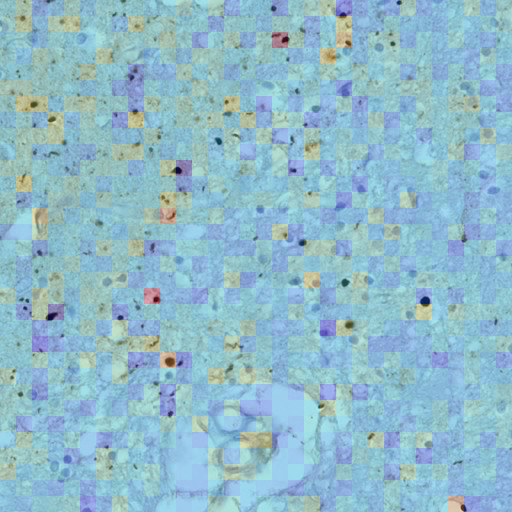

In [93]:
Image.open(images[13])

In [90]:
i,l = 11,"9"
for q in range(len(questions)):
    json_line = {"image":images[i],"query":questions[q],"label":answers[l]}
    all_jsons.append(json_line)

In [91]:
all_jsons


[{'image': '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/images/DLB-99-1147-C34-45-EntCxDam-Hippocampus_files_76_50.pngattn.png',
  'query': 'what kind of matter is this? Explain what you see in attention map',
  'label': 'Gray Matter. Attention Map. Red - Lewy Bodies, Yellow - Neurons/small aggregates, Blue - Glial Cells'},
 {'image': '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/images/DLB-99-1147-C34-45-EntCxDam-Hippocampus_files_76_50.pngattn.png',
  'query': 'Which type of brain matter is shown here? Describe what is visible in the attention map.',
  'label': 'Gray Matter. Attention Map. Red - Lewy Bodies, Yellow - Neurons/small aggregates, Blue - Glial Cells'},
 {'image': '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/images/DLB-99-1147-C34-45-EntCxDam-Hippocampus_files_76_50.pngattn.png',
  'query': 'Identify

In [ ]:
# Write to a JSON file
with open("output.json", "w") as f:
    json.dump(all_jsons, f, indent=4)

In [5]:
with open("lbd_qa_corpus.json", "r") as f:
    l = json.load(f)

In [12]:
new_rag_json = []
for i in range(len(l)):
    new_rag_json.append({"id":10+i, "text":l[i]["label"], "image_url":l[i]["image"] })

In [13]:
new_rag_json

[{'id': 10,
  'text': 'Gray Matter. No Attention Map',
  'image_url': '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/images/PD92_C110-115_EntCx_files_84_61.png'},
 {'id': 11,
  'text': 'Gray Matter. No Attention Map',
  'image_url': '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/images/PD92_C110-115_EntCx_files_84_61.png'},
 {'id': 12,
  'text': 'Gray Matter. No Attention Map',
  'image_url': '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/images/PD92_C110-115_EntCx_files_84_61.png'},
 {'id': 13,
  'text': 'Gray Matter. No Attention Map',
  'image_url': '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/images/PD92_C110-115_EntCx_files_84_61.png'},
 {'id': 14,
  'text': 'Gray Matter. No Attention Map',
  'image_url': '/gladstone/finkbeiner/steve/work/data/npsad_data/

In [14]:
# Write to a JSON file
with open("rag_output.json", "w") as f:
    json.dump(new_rag_json, f, indent=4)

## New annotations

In [2]:
image_folder = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/images"

In [3]:
json_folder = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/jsons"

In [4]:
images = glob(os.path.join(image_folder,"*.png"))

In [5]:
jsons = glob(os.path.join(json_folder,"*.json"))

In [6]:
image1 = jsons[2].replace("jsons","images").replace(".json",".png")

In [15]:
def check_attention(image1, class_):
    heatmap_bgr = cv2.imread(image1)
    heatmap_gray = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2GRAY)
    heatmap_norm = heatmap_gray / 255.0  # Scale to [0, 1]
    heatmap_resized = cv2.resize(heatmap_norm, (1024,1024), interpolation=cv2.INTER_LINEAR)

    H, W = (1024,1024)
    mask = np.zeros((H, W), dtype=np.uint8)
    contours = [np.array(cnt).astype(np.int32) for cnt in data[class_]]
        
    masked_cnts = cv2.drawContours(mask, contours, -1, color=255, thickness=-1)

    binary_mask = (masked_cnts > 127).astype(float) / 255.0

    # 3. Calculate "Attention Inside Object"
    total_attention = np.sum(heatmap_resized)
    attention_in_mask = np.sum(heatmap_resized * binary_mask)
    
    mean_attention_in_mask = np.mean(heatmap_resized[binary_mask > 0])
    percentage_inside = (attention_in_mask / total_attention) * 10000
    print(f"{percentage_inside:.2f}% of the model's focus is on the object.")
    print(f"{mean_attention_in_mask:.2f} attention_in_mask")

In [16]:
jsons = glob(os.path.join(json_folder,"*.json"))

In [17]:
for json_file in jsons:
    with open(json_file, "r") as f:
        data = json.load(f)
    if len(data)>0:
        image1 = json_file.replace("jsons","images").replace(".json",".png")
        print("Running for file ", json_file.split("/")[-1] )
        if "2" in data:
            print("Lewy Neurites")
            check_attention(image1, "2")
        if "1" in data:
            print("Lewy Bodies")
            check_attention(image1, "1")
    

Running for file  PD334-EntCx-C34-45_files_47_63.json
Lewy Neurites
0.00% of the model's focus is on the object.
0.71 attention_in_mask
Lewy Bodies
0.01% of the model's focus is on the object.
0.26 attention_in_mask
Running for file  PD88_C110-115_EntCx_files_59_39.json
Lewy Neurites
0.02% of the model's focus is on the object.
0.43 attention_in_mask
Running for file  PD177_C110-115_Amygdala_files_33_24.json
Lewy Bodies
0.02% of the model's focus is on the object.
0.29 attention_in_mask
Running for file  PD177_C110-115_Amygdala_files_62_53.json
Lewy Neurites
0.01% of the model's focus is on the object.
0.48 attention_in_mask
Running for file  2015-007-C34-45-Striatum_files_62_1.json
Lewy Bodies
0.02% of the model's focus is on the object.
0.27 attention_in_mask
Running for file  DLB-92-1434-C34-45-Amygdala_files_78_40.json
Lewy Bodies
0.00% of the model's focus is on the object.
0.25 attention_in_mask
Running for file  PD89-DLB--EntCx-C110-115_files_88_18.json
Lewy Neurites
0.01% of th

In [49]:
questions = ["The left image displays the original histology slide where brown-stained aggregates correspond to Lewy Bodies on neurons and Lewy Neurites on neurites. The right image presents the attention map — identify which cell types (neurons, oligodendrocytes, glial cells, Lewy Bodies, Lewy Neurites, astrocytes) are being highlighted, with red representing high activation and blue representing low activation.",
"In the first image, you can see the original tissue section with brown aggregates indicating Lewy Bodies when associated with neurons and Lewy Neurites when found on neurites. The second image is an attention heatmap — describe which cell types like neurons, glial cells, oligodendrocytes, astrocytes, Lewy Bodies, and Lewy Neurites are emphasized, where red means strong focus and blue means weak focus.",
"The original histology image is shown on the left, with brown deposits representing Lewy Bodies on neuronal cells and Lewy Neurites on neurite structures. The accompanying attention map on the right uses red for high and blue for low activation — analyze which cell types including neurons, oligodendrocytes, glial cells, Lewy Bodies, Lewy Neurites, and astrocytes the model is attending to.",
"Shown first is the raw microscopy image containing brown aggregates classified as Lewy Bodies when overlapping neurons and Lewy Neurites when on neurites. The second image is the model's attention map — based on the color gradient from blue (low) to red (high activation), indicate which cell types such as neurons, astrocytes, oligodendrocytes, glial cells, Lewy Bodies, and Lewy Neurites are being focused on.",
"The left panel is the original stained image where brown-colored aggregates are identified as Lewy Bodies if present on neurons and Lewy Neurites if on neurite processes. The right panel shows an attention heatmap — using the red (high) to blue (low) scale, determine which cell types like neurons, glial cells, oligodendrocytes, astrocytes, Lewy Bodies, and Lewy Neurites receive the most attention.",
"Image one is the original pathology slide featuring brown aggregates that represent Lewy Bodies on neurons and Lewy Neurites on neurite structures. Image two is the corresponding attention map where red signifies high model activation and blue signifies low — identify which cell categories including neurons, oligodendrocytes, astrocytes, glial cells, Lewy Bodies, and Lewy Neurites are being highlighted.",
"The first panel presents the unprocessed histological image with brown deposits corresponding to Lewy Bodies when localized on neurons and Lewy Neurites when on neurites. The second panel visualizes the attention map — describe which cell types (neurons, glial cells, astrocytes, oligodendrocytes, Lewy Bodies, Lewy Neurites) show high activation (red) versus low activation (blue).",
"On the left is the original tissue image where brown-stained aggregates are Lewy Bodies if they appear on neuronal cells and Lewy Neurites if found on neurite extensions. On the right is an attention heatmap — analyze the color distribution from red (high focus) to blue (low focus) and specify which cell types like neurons, oligodendrocytes, glial cells, astrocytes, Lewy Bodies, and Lewy Neurites the model prioritizes.",
"The original microscopy image appears first, showing brown aggregates that indicate Lewy Bodies when situated on neurons and Lewy Neurites when on neurite processes. The attention map follows, using a red-to-blue gradient for high-to-low activation — point out which cell types among neurons, astrocytes, oligodendrocytes, glial cells, Lewy Bodies, and Lewy Neurites are most activated.",
"Displayed first is the source histology image containing brown aggregates — these are Lewy Bodies when co-localized with neurons and Lewy Neurites when associated with neurites. The adjacent attention map uses red to indicate high and blue to indicate low model attention — explain which cell types such as neurons, glial cells, oligodendrocytes, astrocytes, Lewy Bodies, and Lewy Neurites are being captured."]

In [32]:
all_jsons = []

In [36]:
i=0

In [41]:
#for i in range(len(jsons)):
json_file= jsons[i]
with open(json_file, "r") as f:
    data = json.load(f)
attn_img = json_file.replace("jsons","images").replace(".json",".pngattn.png")
image1 = json_file.replace("jsons","images").replace(".json",".png")

img1 = cv2.imread(image1)
img2 = cv2.imread(attn_img)

# resize second image to match first image height
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

combined = cv2.hconcat([img1, img2])

output_path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/attn_images_combined/'+image1.split("/")[-1]

#cv2.imwrite(output_path, combined)
if len(data)>0:
    print("Running for file ", json_file.split("/")[-1] )
    if "2" in data:
        print("Lewy Neurites")
        check_attention(image1, "2")
    if "1" in data:
        print("Lewy Bodies")
        check_attention(image1, "1")

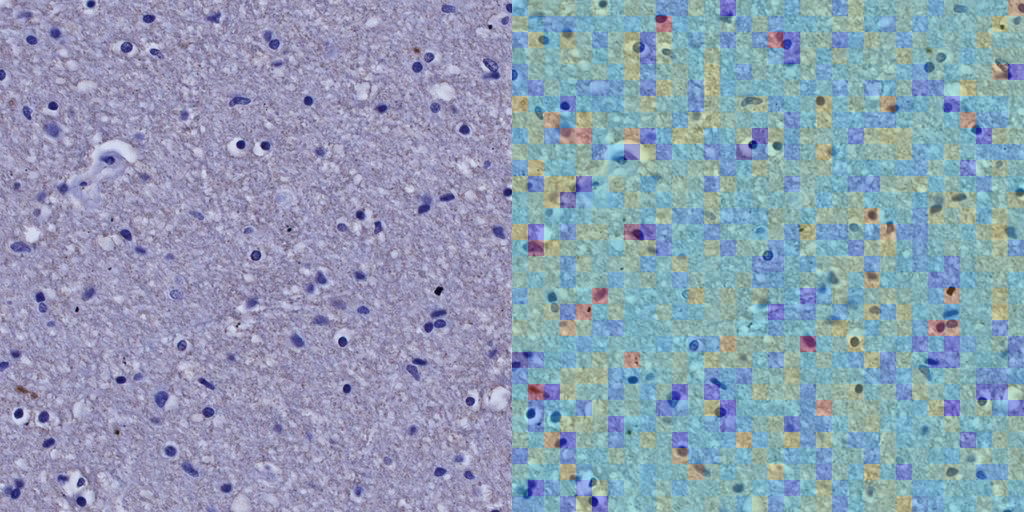

In [42]:
Image.open(output_path)

In [51]:
json_file = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/generated_output.json"
with open(json_file, "r") as f:
    data1 = json.load(f)

In [55]:
print(data1[1]["label"][0])

The right image shows attention maps, which highlight areas of interest in the original image. Here is a color-coded interpretation of the highlighted cell types:

- **Red (High Activation):**
  - **Lewy Bodies:** These are the brown aggregates in the original image.
  - **Lewy Neurites:** These are the brown aggregates on neurites.
  - **Astrocytes:** These are the cells with a more granular appearance.

- **Blue (Low Activation):**
  - **Neurons:** These are the cells with a more uniform appearance.
  - **Oligodendrites:** These are the cells with a more elongated appearance.
  - **Glial Cells:** These are the cells with a more granular appearance.

The attention maps indicate that the model is focusing on the Lewy Bodies and Lewy Neurites (brown aggregates) as well as astrocytes (granular cells) in the original image. The neurons (uniform cells) and oligodendrites (elongated cells) are less highlighted, indicating lower activation by the model.


In [57]:
data1[i]["label"][0].split("\n\n-")

['The right image shows attention maps, which highlight areas of the image that the model is focusing on. Here is a color-coded interpretation of the highlighted areas:',
 ' **Red (High Activation):**\n  - **Neurons:** The red areas are likely highlighting neurons, as they are the primary cells of interest in this context.\n  - **Lewy Bodies:** The red areas might also be highlighting Lewy Bodies, which are aggregates of proteins found in neurons.\n  - **Lewy Neurites:** The red areas could be highlighting Lewy Neurites, which are elongated structures that are part of neurons.',
 " **Blue (Low Activation):**\n  - **Oligodendrites:** The blue areas are likely highlighting oligodendrites, which are cells that produce myelin sheaths around axons.\n  - **Glial Cells:** The blue areas might also be highlighting glial cells, which are supportive cells in the nervous system.\n  - **Astrocytes:** The blue areas could be highlighting astrocytes, which are star-shaped cells that provide structur

In [61]:
import re

matches = re.findall(r'\*\*(.*?)\*\*', data1[i]["label"][0].split("\n\n-")[1])
matches
matches = [m.strip(':') for m in re.findall(r'\*\*(.*?)\*\*', data1[i]["label"][0].split("\n\n-")[1])]
matches

['Red (High Activation)', 'Neurons', 'Lewy Bodies', 'Lewy Neurites']

In [63]:
matches = [m.strip(':') for m in re.findall(r'\*\*(.*?)\*\*', data1[i]["label"][0].split("\n\n-")[2])]
matches

['Blue (Low Activation)', 'Oligodendrites', 'Glial Cells', 'Astrocytes']

In [77]:
data1[i]["label"][0]

"The right image, which shows attention maps, does not directly indicate which specific cell types such as neurons, oligodendrites, glial cells, Lewy bodies, Lewy neurites, or astrocytes are highlighted. Attention maps are typically used to highlight regions of interest in an image based on the model's predictions or activations. They do not provide information about the specific cell types present in the image.\n\nTo determine which cell types are highlighted in the right image, you would need to analyze the model's predictions or activations and compare them to the original image. This would involve understanding the model's output and how it relates to the different cell types in the image."

In [81]:
all_jsons_final = []
for i in range(len(data1)):
    try:
        text = data1[i]["label"][0].split("\n-")
        red_activations = [m.strip(':') for m in re.findall(r'\*\*(.*?)\*\*', text[1])]
        blue_activations = [m.strip(':') for m in re.findall(r'\*\*(.*?)\*\*',text[2])]
    

        d = {"image" : data[i]["image"],
        "query":questions[i%10],
        "label": f"{red_activations[0]}:{red_activations[1:]}, {blue_activations[0]}:{blue_activations[1:]}"
        }
        all_jsons_final.append(d)
    except:
        pass
   


In [82]:
all_jsons_final

[{'image': '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/attn_images_combined/PD92_C110-115_EntCx_files_84_61.png',
  'query': 'The left image displays the original histology slide where brown-stained aggregates correspond to Lewy Bodies on neurons and Lewy Neurites on neurites. The right image presents the attention map — identify which cell types (neurons, oligodendrocytes, glial cells, Lewy Bodies, Lewy Neurites, astrocytes) are being highlighted, with red representing high activation and blue representing low activation.',
  'label': "Red (High Activation):['Neurons', 'Lewy Bodies', 'Lewy Neurites'], Blue (Low Activation):['Oligodendrites', 'Glial Cells', 'Astrocytes']"},
 {'image': '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/LLM/data/attn_images_combined/PD131-C34-45-Striatum_files_11_38.png',
  'query': 'In the first image, you can see the original tissue section with brow

In [83]:
with open("lbd_qa_corpus_big.json", "w") as f:
    json.dump(all_jsons_final, f, indent=4)